# Unemployment Analysis in India

**Author:** Abderrahmane Mazygh  
**Objective:** Analyze unemployment trends, compare rural vs urban areas, and assess the impact of Covid-19 using real-world data.

##  Introduction

Unemployment is a key economic indicator that reflects the health of a country’s labor market.
In this project, we analyze unemployment data in India to uncover trends, patterns, and the impact of the Covid-19 pandemic.

##  Data Loading

The dataset is loaded using Pandas and inspected to understand its structure.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 9.92MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5"
print(os.listdir(dataset_path))

['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


In [ ]:
import pandas as pd

file_path = "/root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5/Unemployment in India.csv"
df = pd.read_csv(file_path)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Data Cleaning

Real-world datasets often contain missing or inconsistent values.
This step focuses on cleaning the data to ensure accurate analysis.

In [ ]:
df = df.dropna()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 46.2+ KB


In [ ]:
import pandas as pd
df[' Date'] = pd.to_datetime(df[' Date'])

/tmp/ipython-input-470495547.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[' Date'] = pd.to_datetime(df[' Date'])


In [ ]:
df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [ ]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [ ]:
df = df.rename(columns={
    ' Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    ' Estimated Employed': 'Employed',
    ' Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})

In [ ]:
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


ANALYSE & VISUALISATION DES DONNÉES

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Évolution du chômage dans le temps (global)

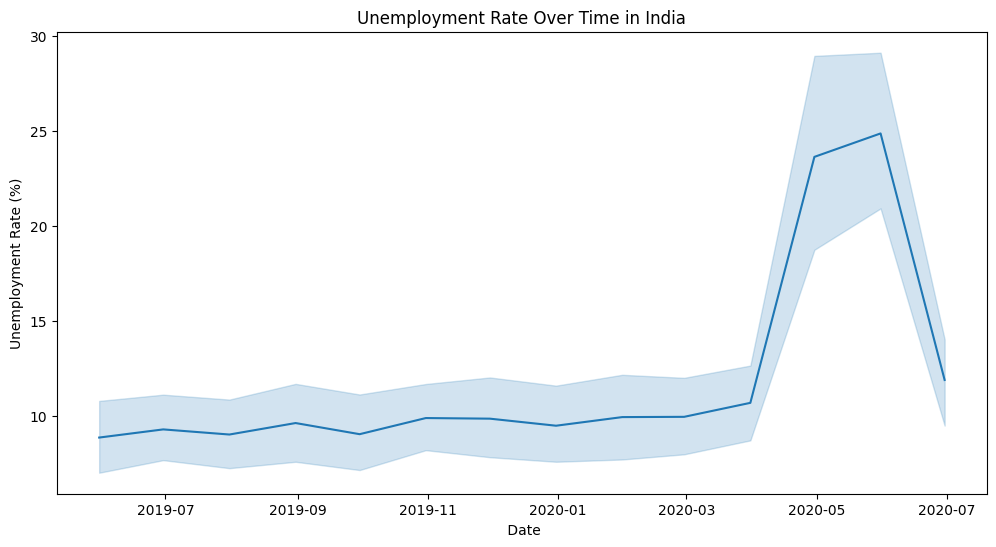

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x=' Date', y='Unemployment_Rate')
plt.title('Unemployment Rate Over Time in India')
plt.xlabel(' Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

Comparaison Rural vs Urban

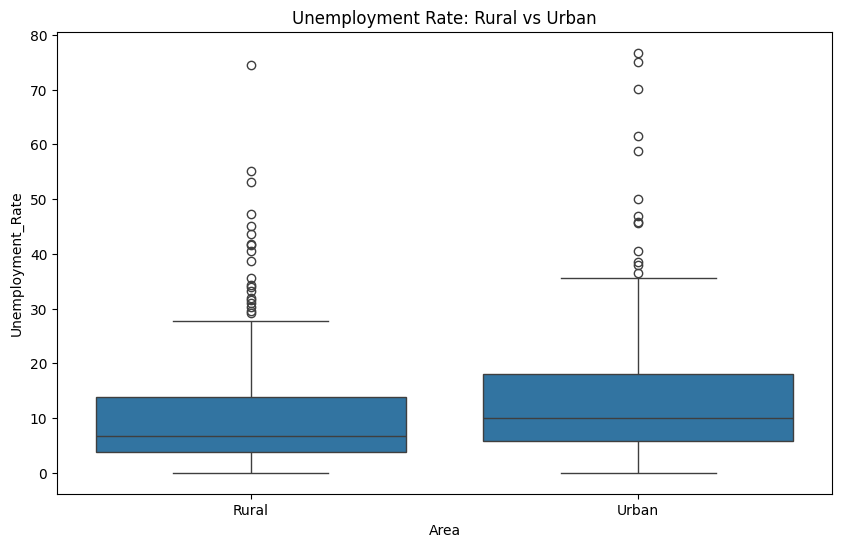

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Area', y='Unemployment_Rate')
plt.title('Unemployment Rate: Rural vs Urban')
plt.show()

Impact du Covid-19

In [ ]:
covid_df = df[df[' Date'].dt.year == 2020]

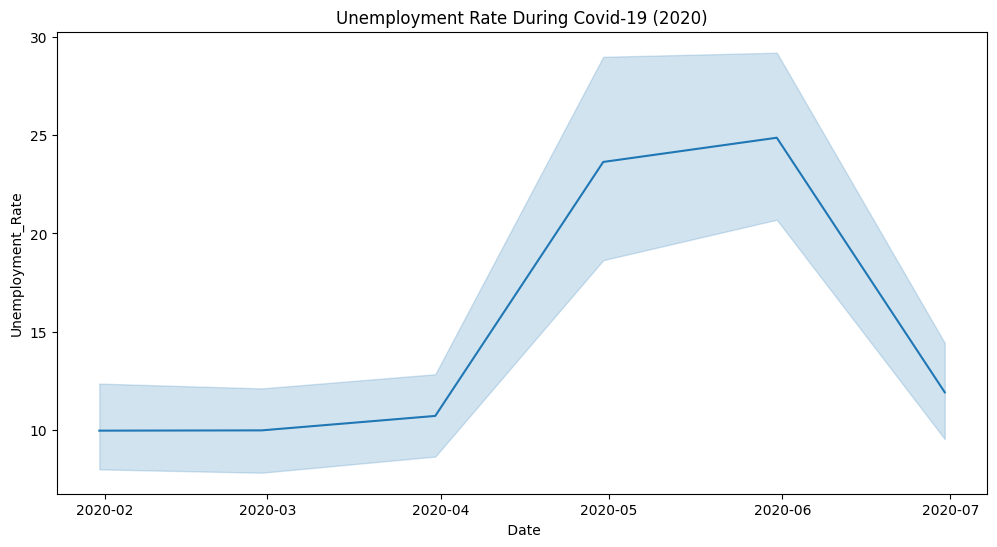

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=covid_df, x=' Date', y='Unemployment_Rate')
plt.title('Unemployment Rate During Covid-19 (2020)')
plt.show()

Moyenne annuelle du chômage

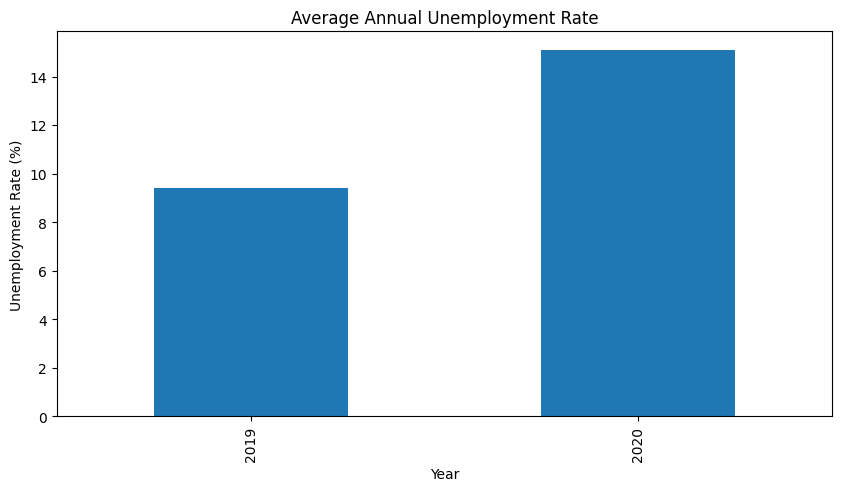

In [ ]:
df['Year'] = df[' Date'].dt.year

yearly_avg = df.groupby('Year')['Unemployment_Rate'].mean()

plt.figure(figsize=(10,5))
yearly_avg.plot(kind='bar')
plt.title('Average Annual Unemployment Rate')
plt.ylabel('Unemployment Rate (%)')
plt.show()

## Key Insights

- The unemployment rate shows significant fluctuations over time, indicating economic instability.
- Urban areas consistently experience higher unemployment rates than rural areas.
- A sharp increase in unemployment is observed during 2020, highlighting the impact of Covid-19.
- Annual averages reveal long-term volatility in the labor market.

##  Limitations and Future Work

### Limitations
- Limited data after 2020
- No sector-specific unemployment information

### Future Improvements
- Apply predictive models
- Add regional and sectoral analysis

## Conclusion

This analysis highlights the importance of data-driven insights in understanding unemployment trends and economic shocks such as Covid-19.